In [185]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [186]:
df = pd.read_csv('heart.csv')
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


The attribute information taken from [kaggle](https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction)

Numerical:
  1. **Age:** Age of the patient in years. Older people more succeptible to heart failure?
  2. **RestingBP:** Resting Blood Pressure measured in mmHg. The normal range is considered to be 90-120. Is >120 correlated with heart failure?
  3. **Cholesterol:** Total cholesterol in mm/dl. Lower than 200 mm/dl is the norm. The high level of cholesterol is >240 mm/dl.
  4.** MaxHR:** Maximum Heart rate, the norm may be considered by formula MaxHR = 208 - (0.7 * age). High values may be linked to heart problems.
  5. **Oldpeak**:  ST-segment depression during exercise compared to the resting state. Values >2 considered a suggestion for heart diseases.

Binary:
  1. **Sex:** Male/Female. Expecting no gender correlation.
  2. **FastingBS:** fasting blood sugar. 1 if FastingBS > 120 mg/dl, 0 otherwise. Value 1 as a marker for heart failure?
  3. **ExerciseAngina:** exercise-induced angina. Y: Yes, N: No. The chest discomfor that can be the symptom of heart disease.
  
Categorical:
  1. **ChestPainType:** the type of chest pain. TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic. Probably asymptomatic people will be less likely to have heart failure.
  2. **RestingECG:** resting electrocardiogram results. Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria.

  3. **ST_Slope:** the slope of the peak exercise ST segment. Up: upsloping, Flat: flat, Down: downsloping. Up - okay, fkat or down - could be coronary ischemia.

Target:
  0. **HeartDisease:** the output class. 1: heart disease, 0: Normal.

In [187]:
df['ExerciseAngina_bin'] = (df['ExerciseAngina'] == 'Y').astype(int)
df['Sex_bin'] = (df['Sex'] == 'M').astype(int)



numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
binary_cols = ['Sex_bin', 'FastingBS', 'ExerciseAngina_bin']
categorical_cols = ['ChestPainType',  'RestingECG', 'ST_Slope']
target_col = 'HeartDisease'

Let's look for outliers

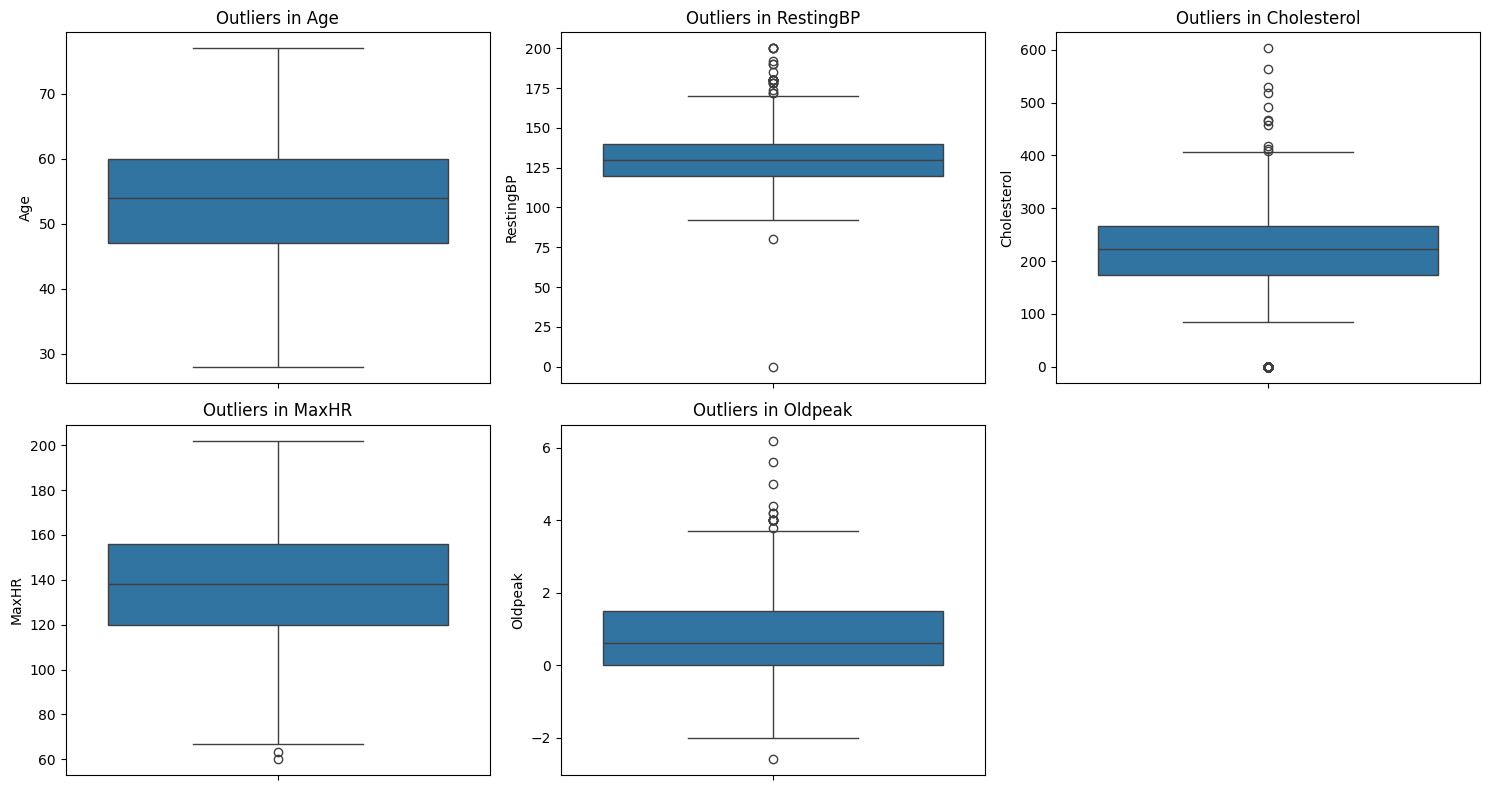

In [188]:
plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

We can see the incorrect values of 0 in RestingBP and Cholesterol cols. Let's remove them.

Removed 172 rows


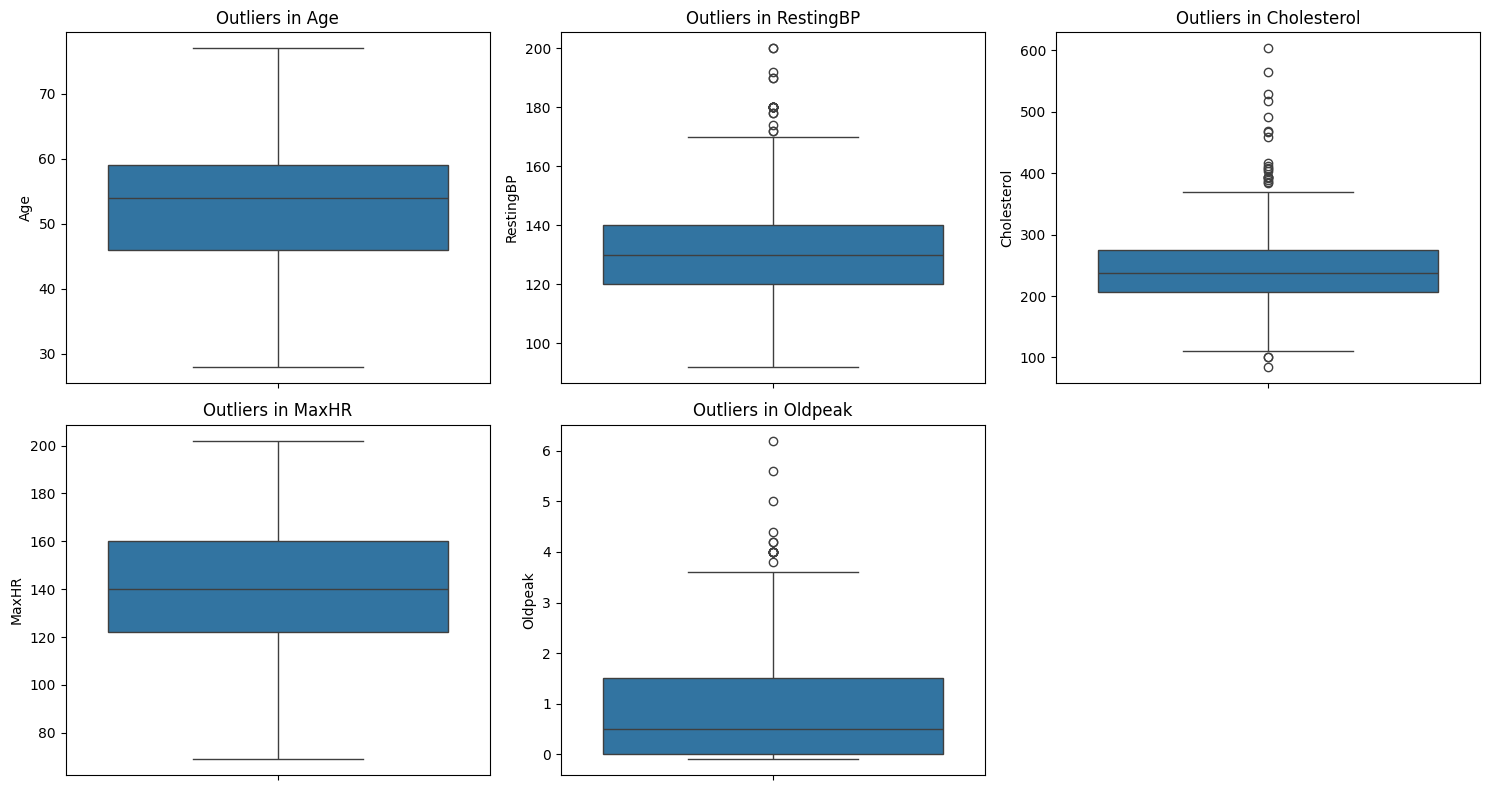

In [189]:
mask = (df['RestingBP'] != 0) & (df['Cholesterol'] != 0 )
df_filtered = df[mask].copy().reset_index()
print(f'Removed {len(df) - len(df_filtered)} rows')

plt.figure(figsize=(15, 8))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df_filtered[col])
    plt.title(f'Outliers in {col}')
plt.tight_layout()
plt.show()

Let's check the distribution of target values

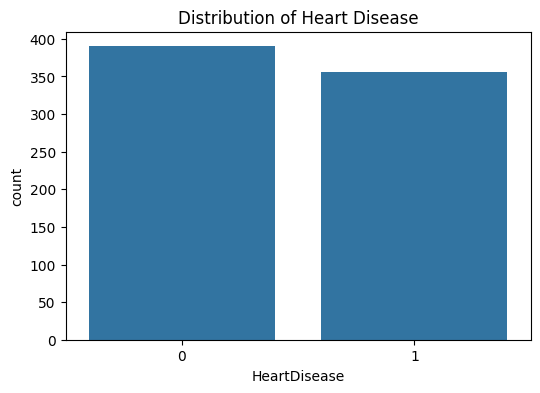

In [190]:
plt.figure(figsize=(6, 4))
sns.countplot(x='HeartDisease', data=df_filtered)
plt.title('Distribution of Heart Disease')
plt.show()

It's a passable imbalance, the counts are almost the same. Let's look at if the categorical values correspond with heart disease in any way.

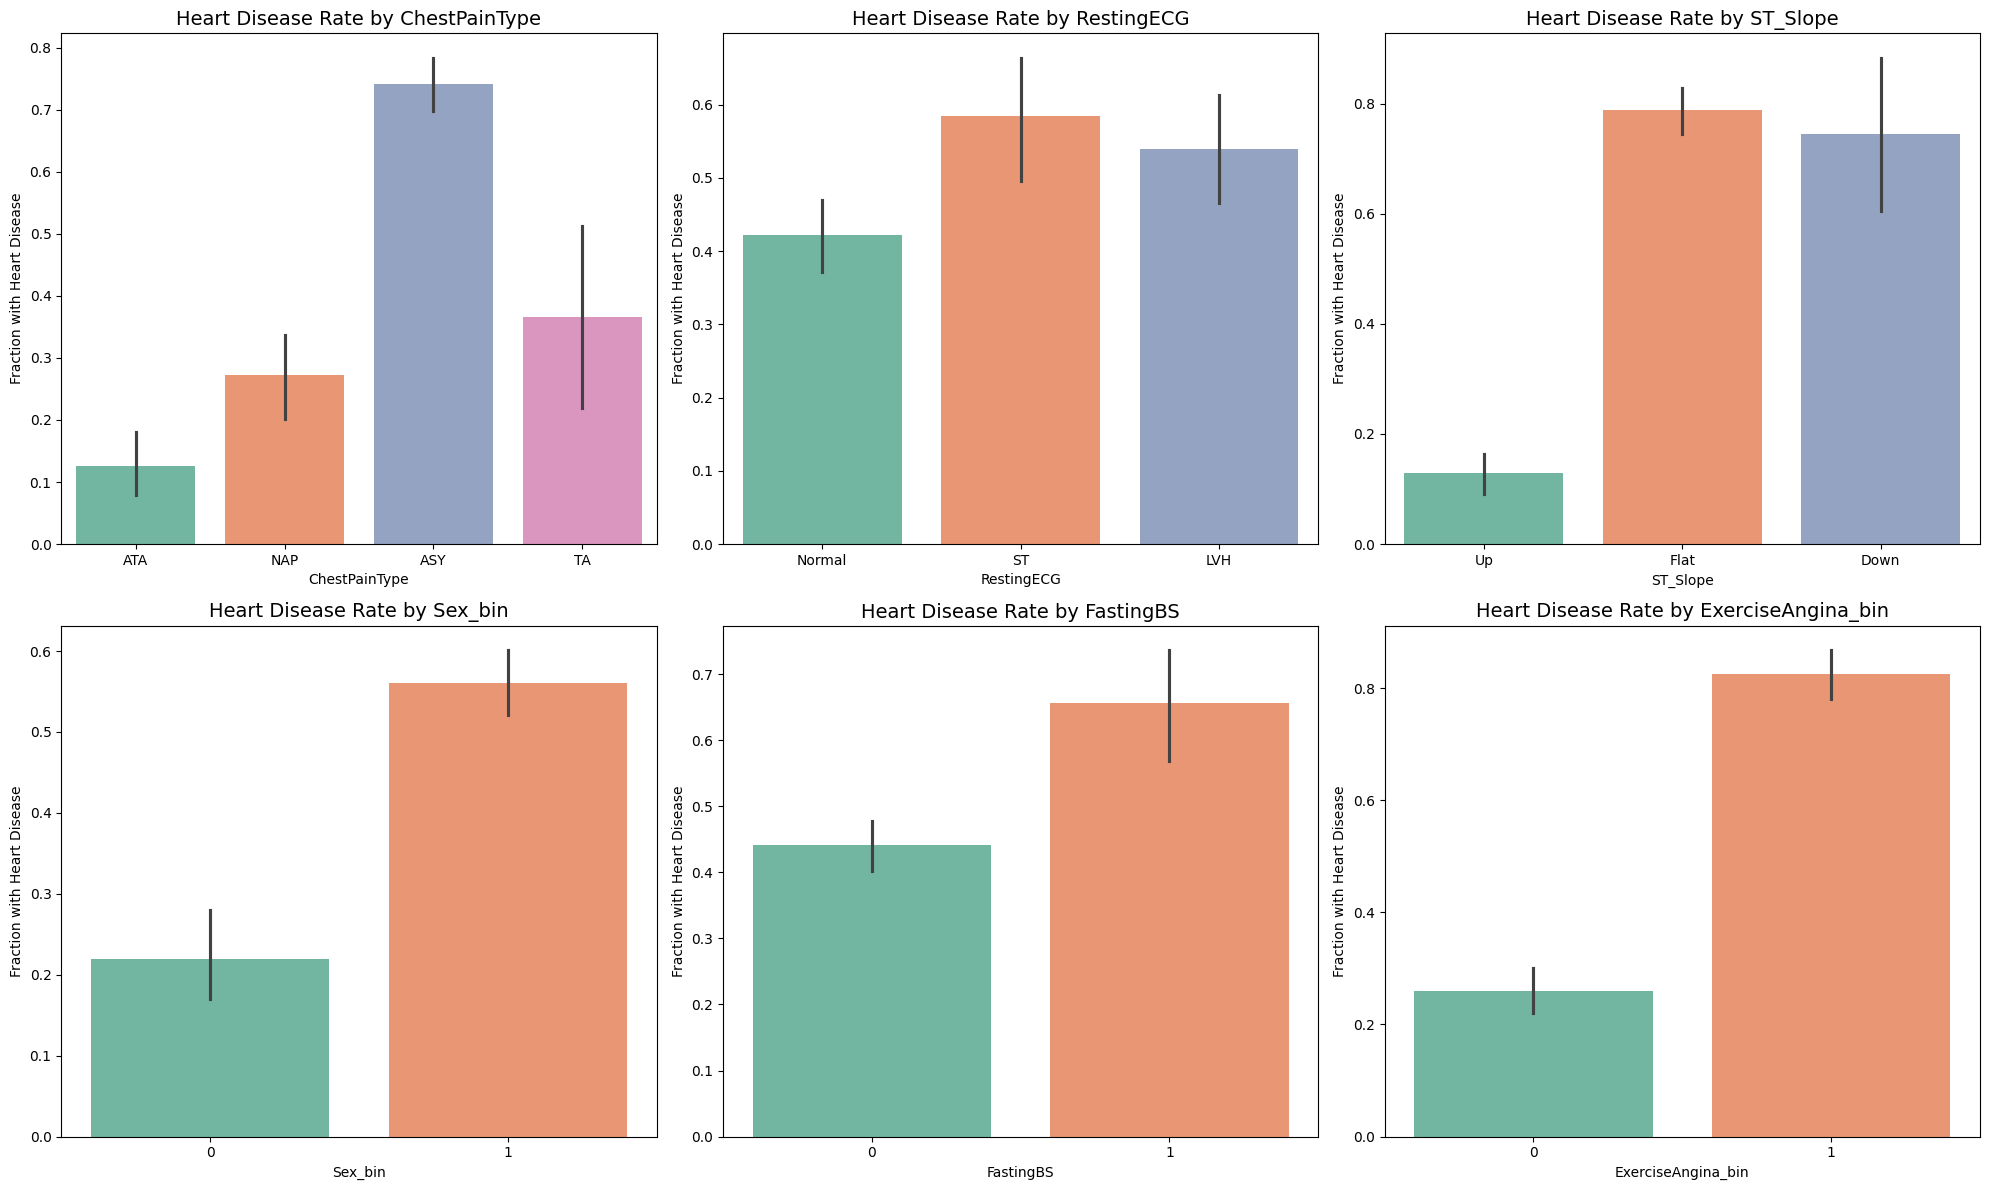

In [191]:
our_cols = categorical_cols + binary_cols

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes_flat = axes.flatten()

for i, col in enumerate(our_cols):
    sns.barplot(
        x=col,
        y='HeartDisease',
        data=df_filtered,
        ax=axes_flat[i],
        hue=col,
        palette='Set2',
        legend=False
    )
    axes_flat[i].set_title(f'Heart Disease Rate by {col}', fontsize=14)
    axes_flat[i].set_ylabel('Fraction with Heart Disease')
    axes_flat[i].set_xlabel(col)

plt.tight_layout()
plt.show()

We can observe that contrary to our assumptions, men seem to be far more likely to have heart diseases than women, as well as people with no symptoms of any chest pain, which makes you wonder... Some of the other predictions are seen: Flat and Down ST slope, FastingBS, ExerciseAngina all tend to show higher risk of Heart disease.

Let's look for correlations in numerical cols.

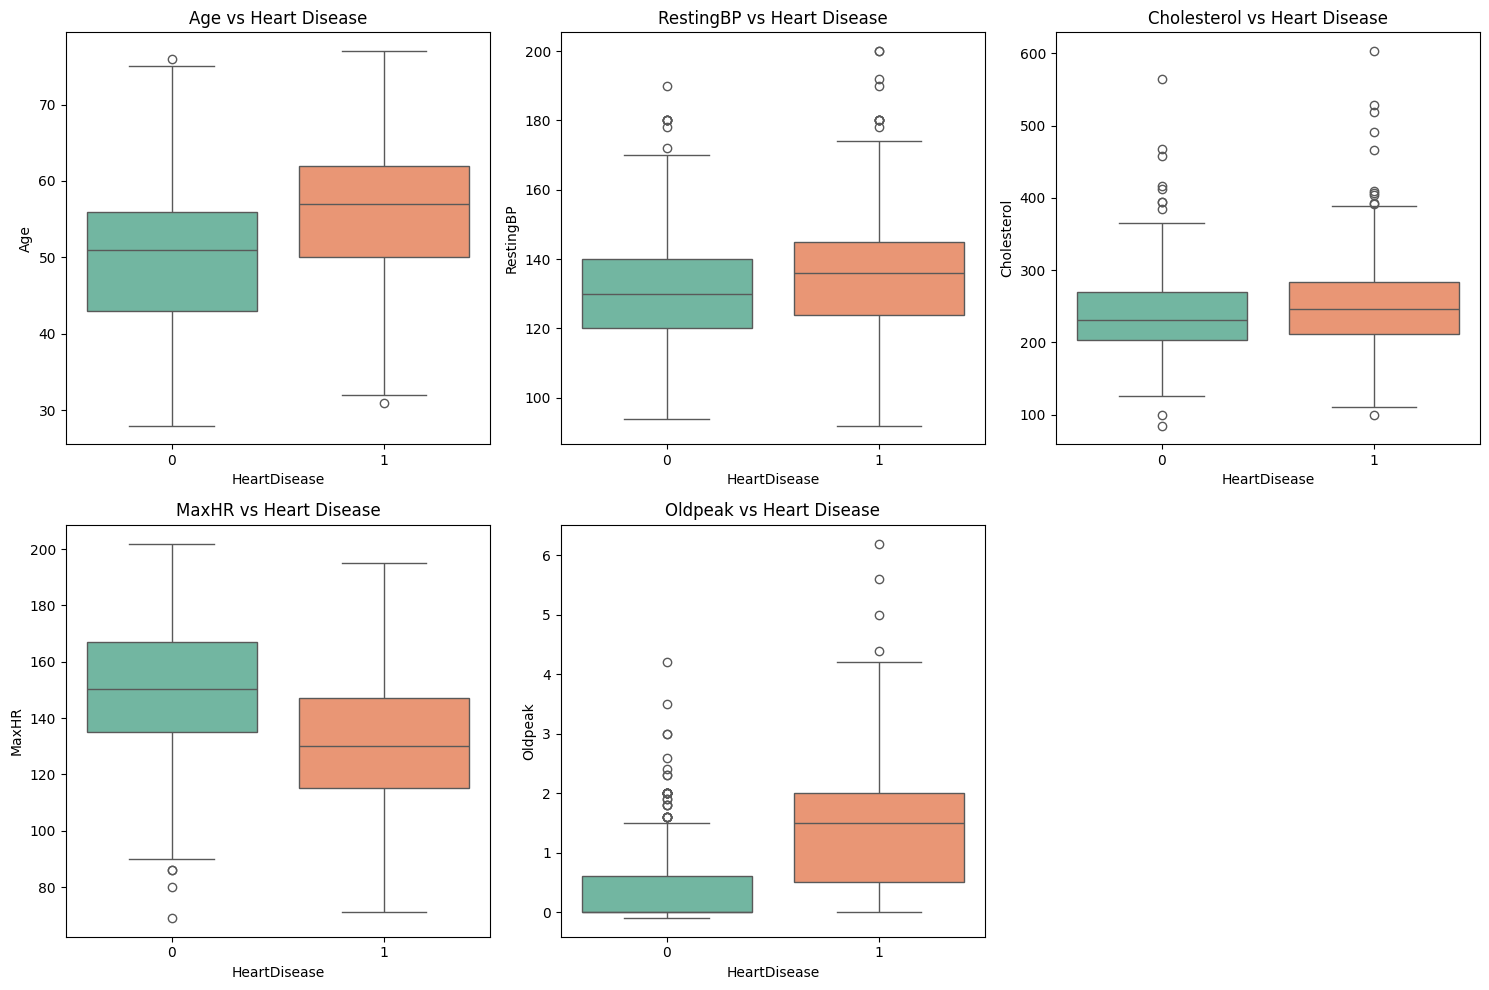

In [192]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 3, i+1)

    sns.boxplot(
        x='HeartDisease',
        y=col,
        data=df_filtered,
        hue='HeartDisease',
        palette='Set2',
        legend=False
    )

    plt.title(f'{col} vs Heart Disease')

plt.tight_layout()
plt.show()

Let's calculate correlation matrix.

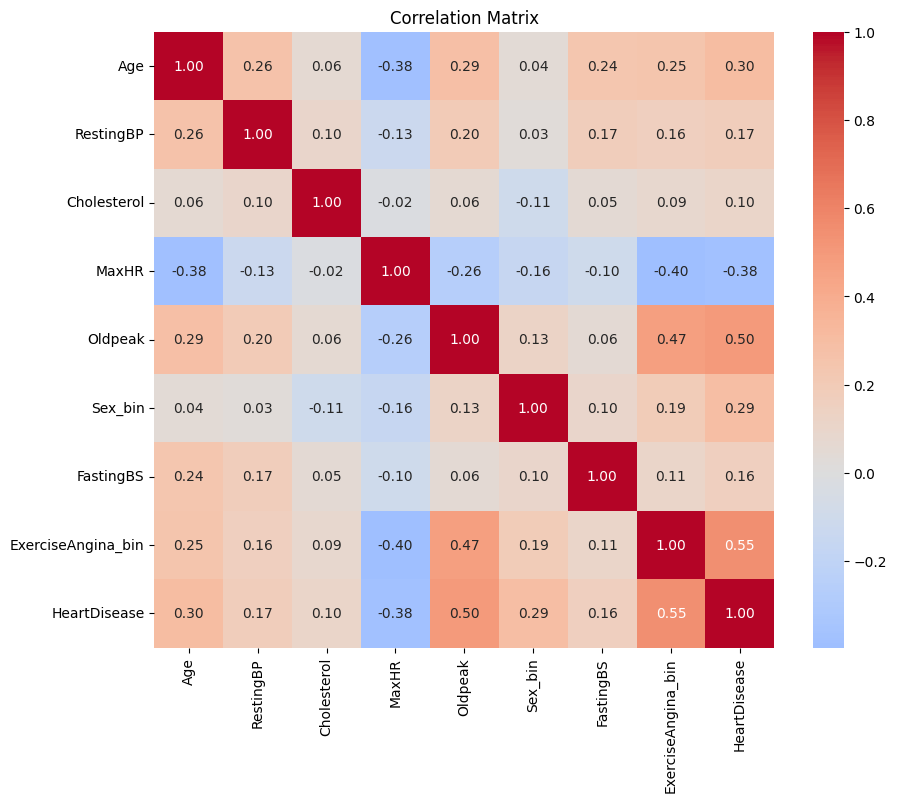

In [197]:
corr_matrix = df_filtered[numerical_cols + binary_cols + [target_col]].corr()


plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

We can observe that the strongest correlation with heart disease are between higher Oldpeak values and Exercise Angina. The others are not so strong though. Also the slight negative correlation between maximum heart rate and heart disease (as well as other features) can be noted. It seems that heart diseases tend to have a range of symptoms, though neither of them would make a distinct marker.

Let's try the multivariate analysis.

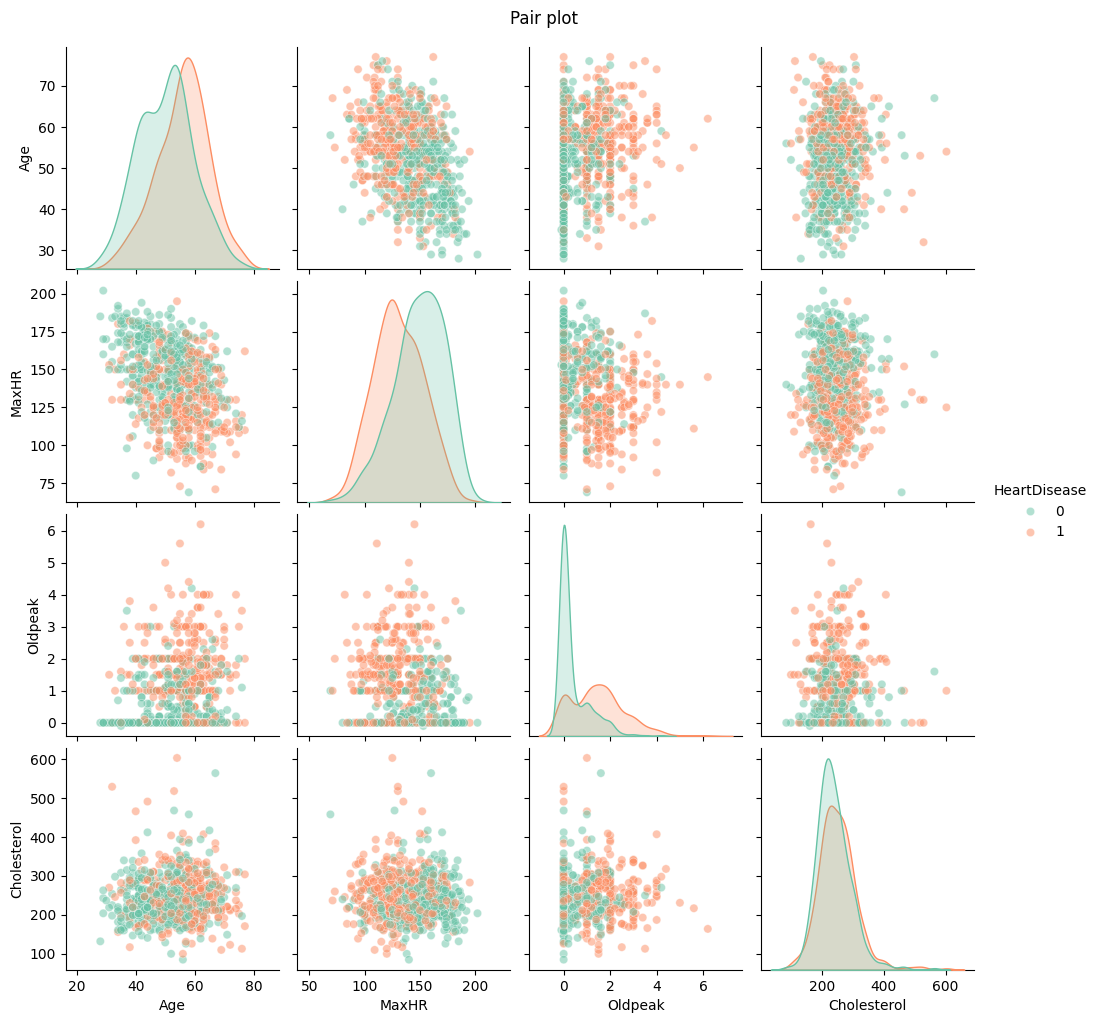

In [135]:
now_cols = ['Age', 'MaxHR', 'Oldpeak', 'Cholesterol', 'HeartDisease']

sns.pairplot(df_filtered[now_cols],
             hue='HeartDisease',
             palette='Set2',
             plot_kws={'alpha': 0.5})
plt.suptitle('Pair plot', y=1.02)
plt.show()

The situation is kinda messy, no clear clusters appear, though tendencies for certain values can be seen. Let's take Age/MaxHR and try to combine the it with oldpeak.

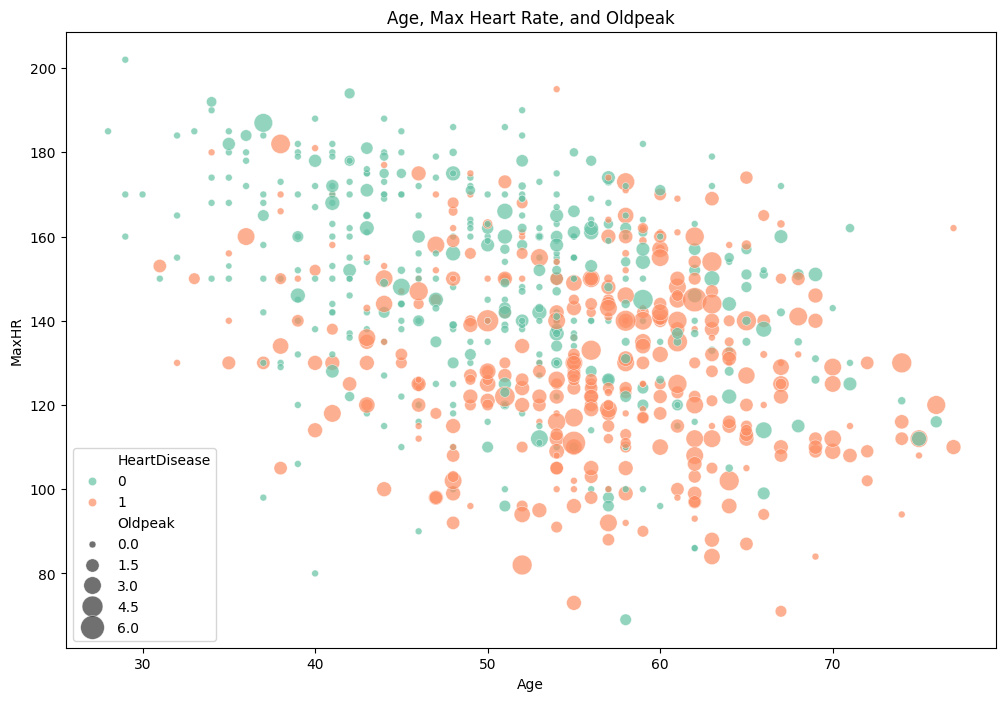

In [132]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_filtered,
                x='Age',
                y='MaxHR',
                hue='HeartDisease',
                size='Oldpeak',
                sizes=(20, 300),
                alpha=0.7,
                palette='Set2')

plt.title('Age, Max Heart Rate, and Oldpeak')
plt.legend()
plt.show()

This way we can see way more clearly the cluster of higher-age, lower-MaxHR and higher-Oldpeak people, that tend to have heart diseases.

Let's engineer some features based on standards that we talked about in the beginning and combine them into one symptoms variable.

In [198]:
df_filtered['HR_Deviation'] = 208 - (0.7 * df_filtered['Age']) - df_filtered['MaxHR']

df_filtered['RestingBP_Abnormal'] = (df_filtered['RestingBP'] > 120).astype(int)

df_filtered['High_Cholesterol'] = (df_filtered['Cholesterol'] > 240).astype(int)

df_filtered['ST_Abnormal'] = (df_filtered['ST_Slope'].isin(['Flat', 'Down'])).astype(int)

df_filtered['Oldpeak_High'] = (df_filtered['Oldpeak'] > 2).astype(int)

df_filtered['Symptoms_Number'] = (
    df_filtered['FastingBS'] +
    df_filtered['RestingBP_Abnormal'] +
    df_filtered['High_Cholesterol'] +
    df_filtered['ST_Abnormal'] +
    df_filtered['Oldpeak_High'] +
    df_filtered['ExerciseAngina_bin']
)

engineered_cols = ['HR_Deviation', 'RestingBP_Abnormal', 'High_Cholesterol',
                   'ST_Abnormal', 'Oldpeak_High', 'Symptoms_Number']

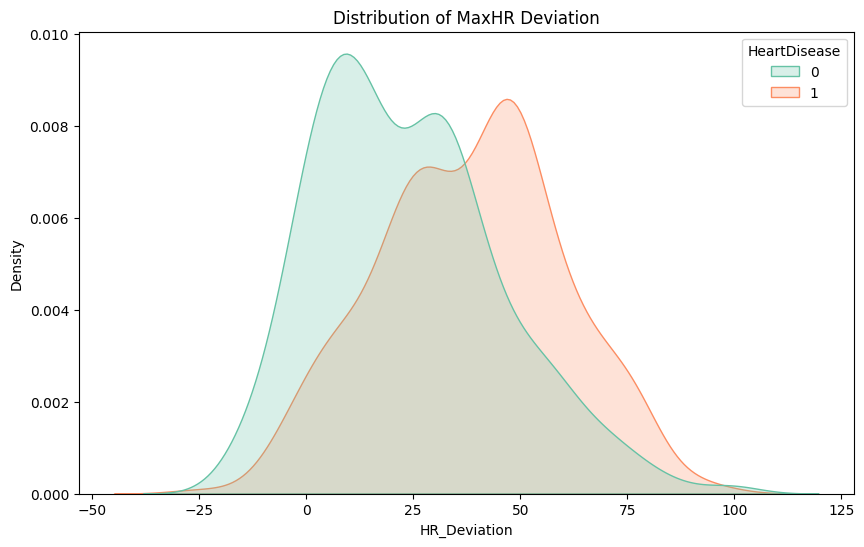

In [171]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_filtered, x='HR_Deviation', hue='HeartDisease', fill=True, palette='Set2')
plt.title('Distribution of MaxHR Deviation')
plt.show()

We can see that, yes, higher MaxHR Deviation tends to show up with heart disease.

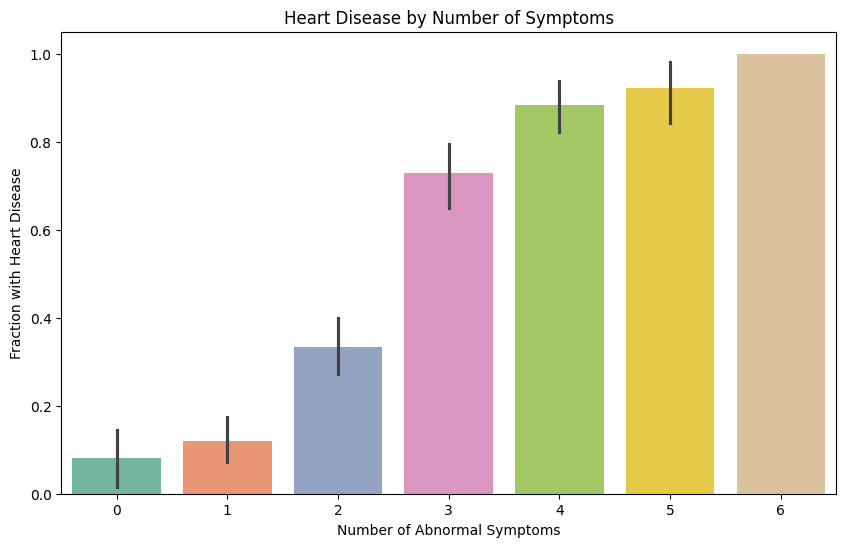

In [167]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Symptoms_Number', y='HeartDisease', data=df_filtered, palette='Set2', hue='Symptoms_Number', legend=False)
plt.title('Heart Disease by Number of Symptoms')
plt.xlabel('Number of Abnormal Symptoms')
plt.ylabel('Fraction with Heart Disease')
plt.show()

We can see that our symptoms variable is somewhat indicative of higher disease rate. Cool. This appears to be our strongest feature yet. Though of course it is more rare for people to have very high symptoms number.

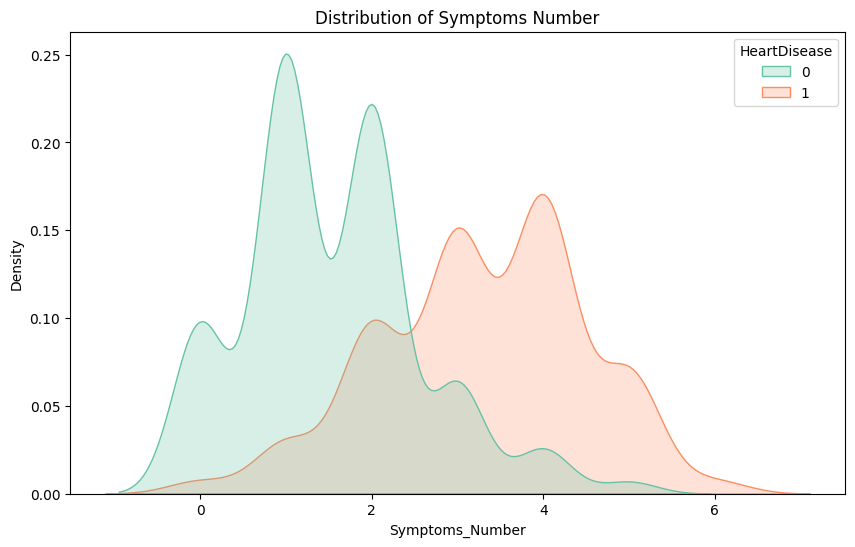

In [170]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_filtered, x='Symptoms_Number', hue='HeartDisease', fill=True, palette='Set2')
plt.title('Distribution of Symptoms Number')
plt.show()

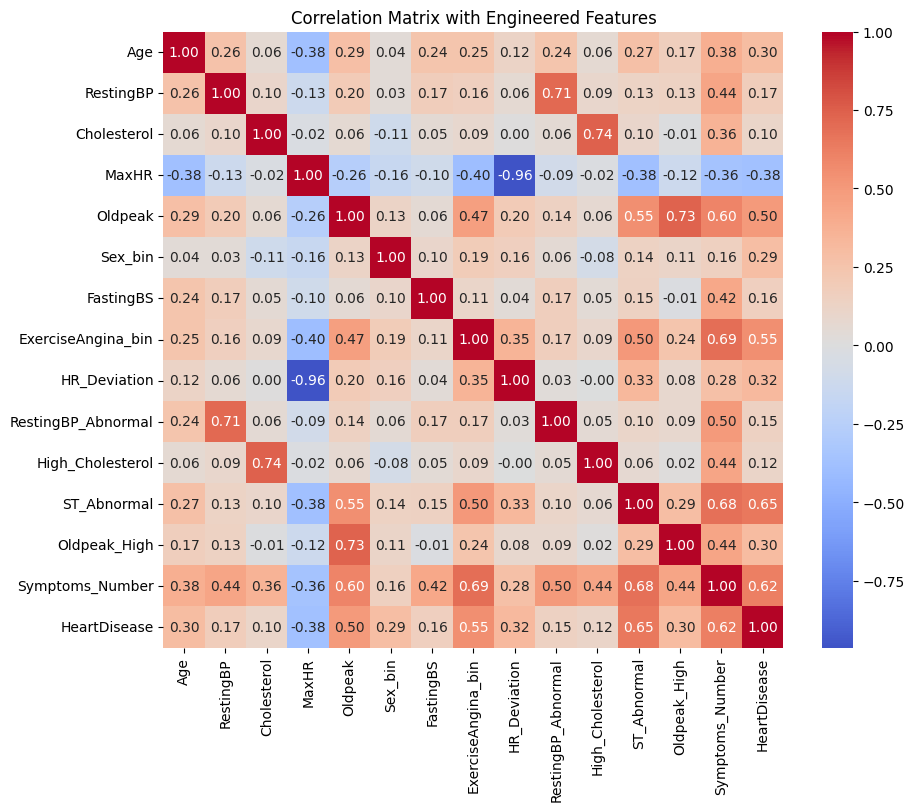

In [200]:
corr_matrix = df_filtered[numerical_cols + binary_cols + engineered_cols +  [target_col]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt=".2f")
plt.title('Correlation Matrix with Engineered Features')
plt.show()

And the highest-correlated feature of the engineered ones seems to be ST-abnormality (Flat/Down)

Overall, I think we can conclude that we could not attribute the disease probability to one specific symptom or feature, taking into the account the heterogeneity of their appearance. Heart diseases have complex causes and complex systems, so our approach should be also holistic. If we were to train a classifier on this dataset we would need to make sure it is balanced by features. Though we identified some high-disease-risk features (Oldpeak, Exercise Angina) and encoded/engineered some too (ST-abnormality, Symptoms Number). Maybe we could have not thrown away the incorrect outliers and retain some information, as it is significant for such a small dataset.